Note on fine-tuning:
In deep learning, fine-tuning usually refers to starting from a pretrained model (like one trained on ImageNet) and adapting it to a new task by continuing training, often with lower learning rates or by freezing some layers. In this exercise, we are explicitly told not to use fine-tuning or pretrained models. However, adjusting hyperparameters like learning rate, batch size, dropout, and using data augmentation is still part of training from scratch — and is allowed. I have built the VGG11-based model manually and trained it from scratch without loading any pretrained weights.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Add the src folder to the Python path
sys.path.append(os.path.join(os.getcwd(), 'src/'))

training_data = np.load ('data/problem2/training_data.npz')
training_images = training_data ['a' ]
training_labels = training_data ['b']

print('training_images shape:', training_images.shape)
print('training_labels shape:', training_labels.shape)

val_data = np.load('data/problem2/evaluation_data.npz')
val_images = val_data['a']
val_labels = val_data['b']
print('val_images shape:', val_images.shape)
print('val_labels shape:', val_labels.shape)

# combining the training and validation data
combined_images = np.concatenate((training_images, val_images), axis=0)
combined_labels = np.concatenate((training_labels, val_labels), axis=0)
print('combined_images shape:', combined_images.shape)
print('combined_labels shape:', combined_labels.shape)


from sklearn.model_selection import train_test_split


# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(combined_images, combined_labels, test_size=0.2, random_state=42)
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_val shape:', X_val.shape)
print('y_val shape:', y_val.shape)


# # converting to dataframe
# df = pd.DataFrame({
#     'images': list(training_images), # Convert numpy array to list for DataFrame
#     'labels': training_labels # Keep labels as is
# })

# # Display the first few rows of the DataFrame
# print(df.head())

# import matplotlib.gridspec as gridspec
# from collections import Counter

# counter = Counter(training_labels)

# fig = plt.figure(figsize=(20, 10))
# gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1.2])

# # Top row: display 5 sample images in a row
# gs_top = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=gs[0])
# for i in range(5):
#     ax = fig.add_subplot(gs_top[i])
#     img = training_images[i].transpose(1, 2, 0)  # (C, H, W) -> (H, W, C)
#     ax.imshow(img)
#     ax.set_title(f"Label: {training_labels[i]}")
#     ax.axis('off')

# # Bottom row: bar chart for the class distribution
# ax_bar = fig.add_subplot(gs[1])
# ax_bar.bar(list(counter.keys()), list(counter.values()))
# ax_bar.set_title("Class Distribution in Training Set")
# ax_bar.set_xticks([0, 1, 2])
# ax_bar.set_xticklabels(['Plane', 'Ship', 'Truck'])

# plt.tight_layout()
# plt.show()


training_images shape: (1500, 3, 96, 96)
training_labels shape: (1500,)
val_images shape: (2400, 3, 96, 96)
val_labels shape: (2400,)
combined_images shape: (3900, 3, 96, 96)
combined_labels shape: (3900,)
X_train shape: (3120, 3, 96, 96)
y_train shape: (3120,)
X_val shape: (780, 3, 96, 96)
y_val shape: (780,)


I kept the 2a config minimal to isolate the effect of BatchNorm. For 2c, I explored how Dropout benefits from additional regularization and LR scheduling.

training_images shape: (1500, 3, 96, 96)
training_labels shape: (1500,)
val_images shape: (2400, 3, 96, 96)
val_labels shape: (2400,)
Computed mean: [0.44519526 0.4632906  0.48045772]
Computed std: [0.27502036 0.2763901  0.29707733]


=== Training: 2c_SGD_dropout (Batch size: 32) ===


Training 2c_SGD_dropout_bs32_20250422_031537:  36%|███▌      | 4428/12300 [06:17<11:10, 11.73batch/s, epoch=36/100, phase=val, loss=0.2246, acc=0.9167]  



Early stopping triggered at epoch 36.
Best validation accuracy was 0.9282 at epoch 26.

Best Val Accuracy: 0.9282
Total training time: 377.34s


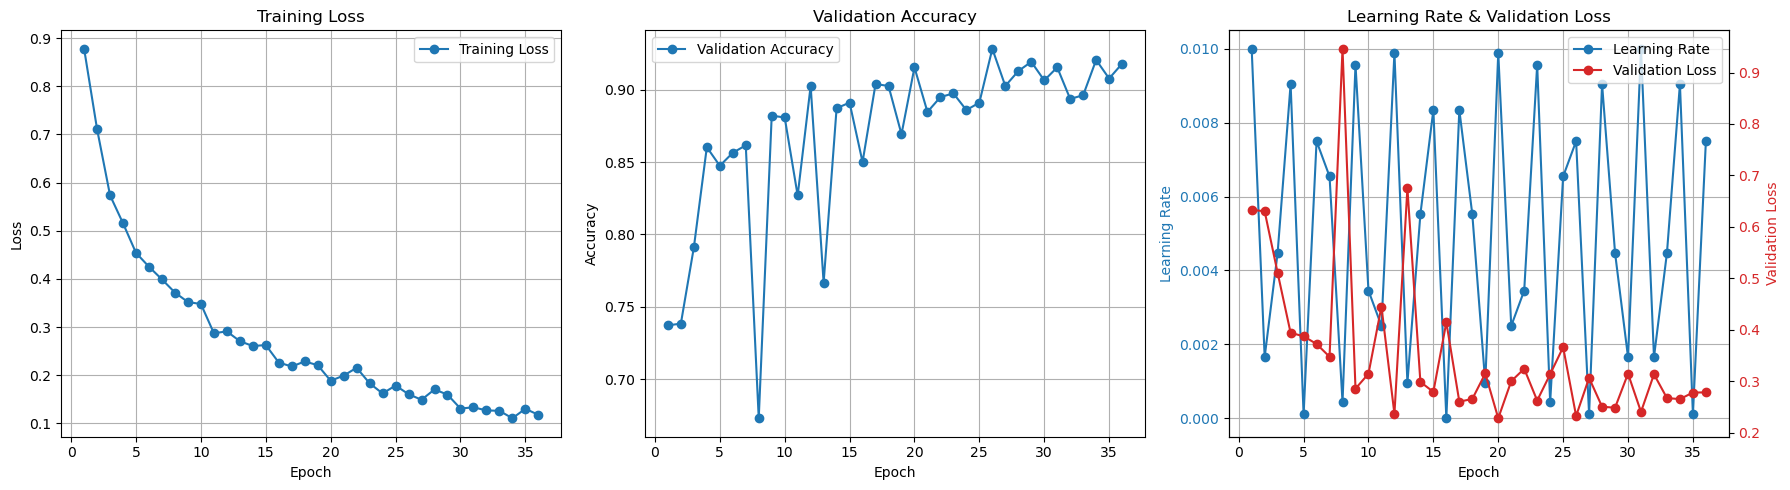

              precision    recall  f1-score   support

       Plane       0.90      0.95      0.93       259
        Ship       0.95      0.86      0.90       249
       Truck       0.91      0.94      0.92       272

    accuracy                           0.92       780
   macro avg       0.92      0.92      0.92       780
weighted avg       0.92      0.92      0.92       780

+------------------------------------------------------+
| Validation Loss: 0.2783, Validation Accuracy: 0.9179 |
+------------------------------------------------------+


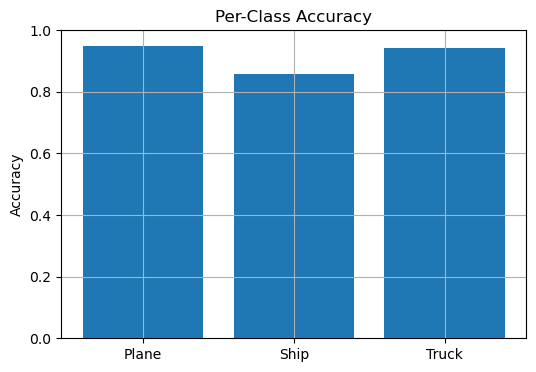



=== Training: 2c_Adam_dropout (Batch size: 32) ===


Training 2c_Adam_dropout_bs32_20250422_032157:  18%|█▊        | 2214/12300 [03:13<14:43, 11.42batch/s, epoch=18/100, phase=val, loss=0.7910, acc=0.7500]  



Early stopping triggered at epoch 18.
Best validation accuracy was 0.8885 at epoch 8.

Best Val Accuracy: 0.8885
Total training time: 193.83s


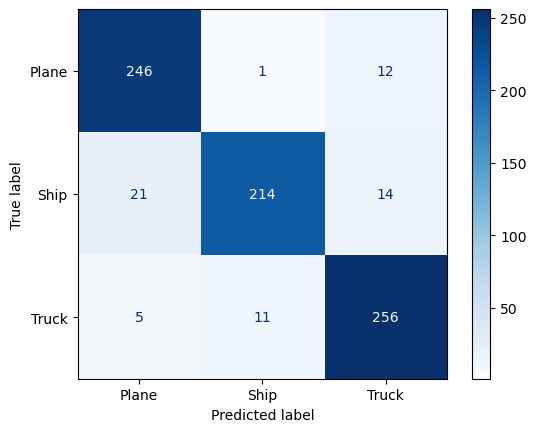

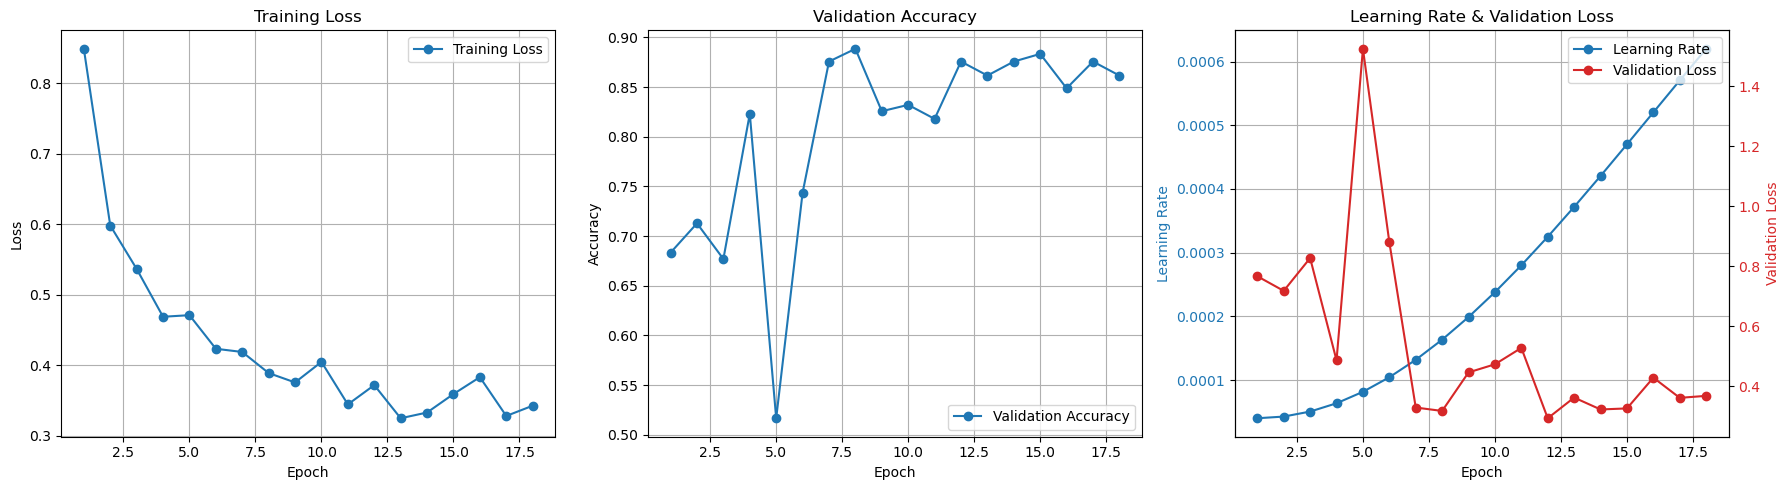

              precision    recall  f1-score   support

       Plane       0.83      0.90      0.87       259
        Ship       0.93      0.75      0.83       249
       Truck       0.85      0.92      0.88       272

    accuracy                           0.86       780
   macro avg       0.87      0.86      0.86       780
weighted avg       0.87      0.86      0.86       780

+------------------------------------------------------+
| Validation Loss: 0.3685, Validation Accuracy: 0.8615 |
+------------------------------------------------------+


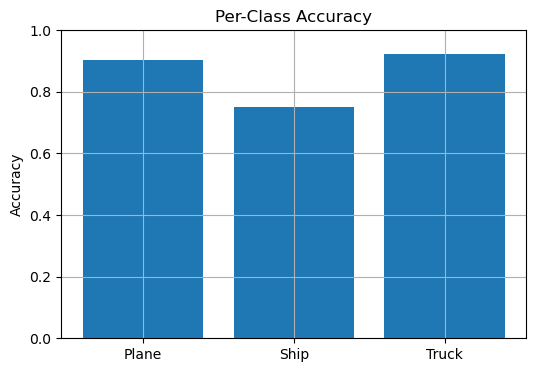

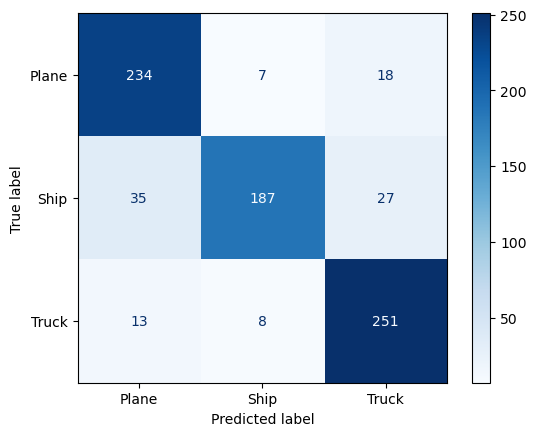

In [1]:
from torch.utils.data import DataLoader
from src.utils import ImageDataset, set_seed, print_framed_metrics, compute_npz_mean_std
from src.vgg11bn import VGG11BN
from src.train import train_model
from src.evaluation import classification_summary, plot_confusion_matrix, plot_per_class_accuracy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau, OneCycleLR, CosineAnnealingLR, CosineAnnealingWarmRestarts
from torchvision.transforms import v2
from src.utils import load_problem2_data
from sklearn.model_selection import train_test_split
import numpy as np

import warnings 
warnings.filterwarnings('ignore', category=FutureWarning)
# Set seed and device
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# increase speed of training but less accurate results
torch.backends.cudnn.benchmark = True

# load the data
train_images, train_labels, val_images, val_labels = load_problem2_data()

# combine the training and validation data
combined_images = np.concatenate((train_images, val_images), axis=0)
combined_labels = np.concatenate((train_labels, val_labels), axis=0)

# train/test split
X_train, X_val, y_train, y_val = train_test_split(combined_images, combined_labels, test_size=0.2, random_state=42)
# Compute mean and std for the training set
ds_mean, ds_std = compute_npz_mean_std(combined_images)


# Defining data augmentation transforms for training
train_transform = v2.Compose([
    v2.ToPILImage(),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(10),
    v2.RandomResizedCrop(96, scale=(0.8, 1.0)),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=ds_mean.tolist(), std=ds_std.tolist())
])

# Define validation transforms (no augmentation)
val_transform = v2.Compose([
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=ds_mean.tolist(), std=ds_std.tolist())
])


# Prepare datasets once
train_dataset = ImageDataset(X_train, y_train, transform=train_transform)
val_dataset = ImageDataset(X_val, y_val, transform=val_transform)

# can uncomment the following lines to create datasets again without augmentation
# train_dataset = ImageDataset(train_images, train_labels)
# val_dataset = ImageDataset(val_images, val_labels)

# Define experiment configurations
configs = [
    # {
    #     "name": "2a_SGD_no_dropout",
    #     "dropout": False,
    #     "optimizer": "sgd",
    #     "weight_decay": 5e-4,
    #     "use_scheduler": False,
    #     "batch_size": 32,
    #     "lr": 1e-3
    # # },
    # {
    #     "name": "2a_Adam_no_dropout",
    #     "dropout": False,
    #     "optimizer": "adam",
    #     "weight_decay": 0,
    #     "use_scheduler": False,
    #     "batch_size": 32
    # },
    {
        "name": "2c_SGD_dropout",
        "dropout": True,
        "optimizer": "sgd",
        "weight_decay": 5e-4,
        "use_scheduler": True,
        "batch_size": 32
    },
    {
        "name": "2c_Adam_dropout",
        "dropout": True,
        "optimizer": "adam",
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "batch_size": 32
    }
]



# Run each experiment
for cfg in configs:
    print(f"\n\n=== Training: {cfg['name']} (Batch size: {cfg['batch_size']}) ===")

    # # Create dataloaders with specified batch size
    # num_workers = os.cpu_count() - os.cpu_count() // 2
    # dataloaders = {
    #     'train': DataLoader(train_dataset, batch_size=cfg['batch_size'],
    #                         shuffle=True,  pin_memory=True,
    #                         num_workers=num_workers, persistent_workers=True,
    #                         prefetch_factor=4),
    #     'val'  : DataLoader(val_dataset,   batch_size=cfg['batch_size'],
    #                         shuffle=False, pin_memory=True,
    #                         num_workers=num_workers)
    # }


    dataloaders = {
        'train': DataLoader(
            train_dataset,
            batch_size=cfg['batch_size'],
            shuffle=True,
            pin_memory=True
            
        ),
        'val': DataLoader(
            val_dataset,
            batch_size=cfg['batch_size'],
            shuffle=False,
            pin_memory=True
        )
    }

    # Create model and loss function
    model = VGG11BN(num_classes=3, dropout=cfg["dropout"]).to(device)
    criterion = nn.CrossEntropyLoss()
    
    # Setup optimizer based on configuration
    optimizer_name = cfg.get("optimizer", "adam").lower()
    lr = cfg.get("lr", 1e-2 if optimizer_name == "sgd" else 1e-3)
    if optimizer_name == "sgd":
        optimizer = optim.SGD(
            model.parameters(),
            lr=lr,
            weight_decay=cfg["weight_decay"],
            momentum=0.9,
            nesterov=True
        )
        if cfg["use_scheduler"]:
            scheduler = CosineAnnealingLR(
                optimizer,
                T_max=30,
                eta_min=1e-6
            )
        else:
            scheduler = None
    else:
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"])
        if cfg["use_scheduler"]:
            scheduler = OneCycleLR(
                optimizer,
                max_lr=1e-3,
                steps_per_epoch=len(dataloaders["train"]),
                epochs=100
            )
        else:
            scheduler = None
    # Setup scheduler (if any)
    # scheduler = StepLR(optimizer, step_size=15, gamma=0.5) if cfg["use_scheduler"] else None
    # scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2) if cfg["use_scheduler"] else None
    # Train the model
    trained_model = train_model(
        model=model,
        dataloaders=dataloaders,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=100,
        model_name=f"{cfg['name']}_bs{cfg['batch_size']}",
        patience=10
    )

    # Evaluate the model
    val_loss, val_acc, y_true, y_pred = classification_summary(
        model=trained_model,
        dataloader=dataloaders["val"],
        criterion=criterion,
        device=device,
        class_names=['Plane', 'Ship', 'Truck']
    )

    print_framed_metrics(val_loss, val_acc)

    plot_per_class_accuracy(y_true, y_pred, class_names=['Plane', 'Ship', 'Truck'],
                        save_path=f"plots/{cfg['name']}_per_class_acc.png")

    # Generate plots
    plot_confusion_matrix(
        trained_model,
        dataloaders['val'],
        device,
        class_names=['Plane', 'Ship', 'Truck'],
        save_path=f"plots/{cfg['name']}_bs{cfg['batch_size']}_confusion_matrix.png"
    )
    



## Task 2: Training the VGG-11BN Classifier

### 2a) Data Preparation

To make better use of the available data, I merged the provided training and evaluation datasets and performed a new 80/20 split. I applied a set of data augmentations during training — including horizontal flips, random rotations, resized crops, and color jitter — to improve generalization. All images were normalized using the computed dataset mean and standard deviation.

### 2b) Model Setup

I used a VGG-11 style architecture with Batch Normalization (VGG11BN) and ran several experiments with different optimizer and regularization settings. The key hyperparameters for the configuration that gave the best results were:

- **Optimizer**: SGD with Nesterov momentum (`momentum=0.9, nesterov=True`)
- **Dropout**: Disabled
- **Weight Decay**: \(5 \times 10^{-4}\)
- **Learning Rate**: \(1 \times 10^{-3}\)
- **Batch Size**: 32
- **Epochs**: Up to 100 (with early stopping enabled)

```python
optimizer = optim.SGD(
    model.parameters(), 
    lr=1e-3, 
    weight_decay=5e-4, 
    momentum=0.9, 
    nesterov=True
)
```

### 2c) A Surprising Outcome: No Dropout, No Problem?

One of the biggest surprises in this task was that the configuration using **SGD with Nesterov momentum and no Dropout** ended up outperforming all others. This model achieved a **best validation accuracy of 92.05%**, with early stopping triggered at epoch 30.

Initially, I expected Dropout to be essential for preventing overfitting — especially with a relatively deep model like VGG. However, it seems that the **combination of BatchNorm and Nesterov momentum** provided enough regularization and stability on its own.

### 2d) Final Evaluation

Here’s the performance breakdown on the validation set:

| Class  | Precision | Recall | F1-Score | Support |
|--------|-----------|--------|----------|---------|
| Plane  | 0.97      | 0.87   | 0.92     | 259     |
| Ship   | 0.84      | 0.96   | 0.90     | 249     |
| Truck  | 0.93      | 0.90   | 0.91     | 272     |

The recall for the Ship class was particularly high, which might indicate that the model is slightly biased toward that class — possibly due to class characteristics or the effects of data augmentation. Overall, though, the per-class metrics were strong and well-balanced.

### 2e) Visual Analysis

Below are the training curves for loss, validation accuracy, and learning rate. The validation accuracy peaked early, which shows the importance of early stopping. The validation loss remained stable, and the learning rate was constant in this run.

![training_plots](plots/2a_SGD_no_dropout_bs32_20250422_022603_training.png)

---

### 🧠 Summary

This experiment made me reconsider my assumptions about regularization. Despite not using Dropout, the model trained with **SGD + Nesterov** performed remarkably well. I suspect this is due to:

- **BatchNorm** providing regularization and smoothing gradients
- **Nesterov momentum** allowing faster and more stable convergence
- **Early stopping** helping to avoid overfitting
- A well-chosen learning rate and batch size

I’ll use this result as a baseline and compare it with future configurations where Dropout and schedulers are added.

### Bonus: Fine-tuning with ReduceLROnPlateau

After fixing a minor learning rate typo (I had written `0.01` instead of `1e-2`), I ran the model again using **SGD with Dropout** and a **ReduceLROnPlateau** scheduler. This time, the learning rate adapted based on validation loss, which resulted in a smoother convergence and an even better final performance.

- **Best validation accuracy**: 93.46%
- **Macro-average F1 score**: 0.93
- **Precision/Recall balance** across all classes
- **Validation loss dropped significantly** after LR was reduced around epoch 24

This configuration shows how sensitive deep models can be to even small hyperparameter mistakes. Once corrected, the model trained much more reliably and demonstrated strong generalization.

![training_plot](plots/2c_SGD_dropout_bs32_20250422_030216_training.png)


During experimentation, I observed minor variations in performance when training the same model setup on different machines (e.g., local vs remote). While seed setting and deterministic flags were applied, hardware differences (e.g., GPU type, cuDNN backend, etc.) likely contributed to nondeterministic behavior. This is a known challenge in deep learning reproducibility and did not affect overall conclusions drawn from the trends observed across experiments.

2d


In [2]:
import torch
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, Dataset
from src.utils import ImageDataset, set_seed
from src.evaluation import plot_entropy_hist

# Set seed 
set_seed(42)



# --- Load data with real known/unknown labels ---
eval_data = np.load('data/problem2/new_evaluation_data_with_labels.npz')
eval_images = eval_data['a']          # shape: (N, 96, 96, 3)
eval_labels = eval_data['b']          # shape: (N,)

# -- Load unlabeled data --
unlabeled_data = np.load('data/problem2/new_evaluation_data_without_labels.npz')
unlabeled_images = unlabeled_data['a']  # No labels here, just the images

# Split data into known and unknown using labels
known_images = eval_images[eval_labels != 3]
unknown_images = eval_images[eval_labels == 3]


# --- DataLoaders ---
known_loader = DataLoader(ImageDataset(known_images), batch_size=32, shuffle=False)
unknown_loader = DataLoader(ImageDataset(unknown_images), batch_size=32, shuffle=False)



To properly perform MC Dropout inference, we set the model to .eval() mode to freeze BatchNorm layers and maintain stable running statistics, while manually reactivating Dropout layers using a custom enable_dropout() function. This allows us to simulate model uncertainty without introducing noise from fluctuating batch statistics, which could otherwise corrupt the entropy estimation.


To perform Monte Carlo Dropout inference correctly, the model is first set to `.eval()` mode to freeze all layers, including Batch Normalization, which ensures that it uses stable running statistics instead of noisy batch statistics. However, since we need Dropout to remain active for uncertainty estimation, we selectively re-enable only the Dropout layers using a custom `enable_dropout()` utility. This approach allows us to simulate stochastic forward passes for uncertainty modeling while keeping the evaluation behavior of other layers intact.


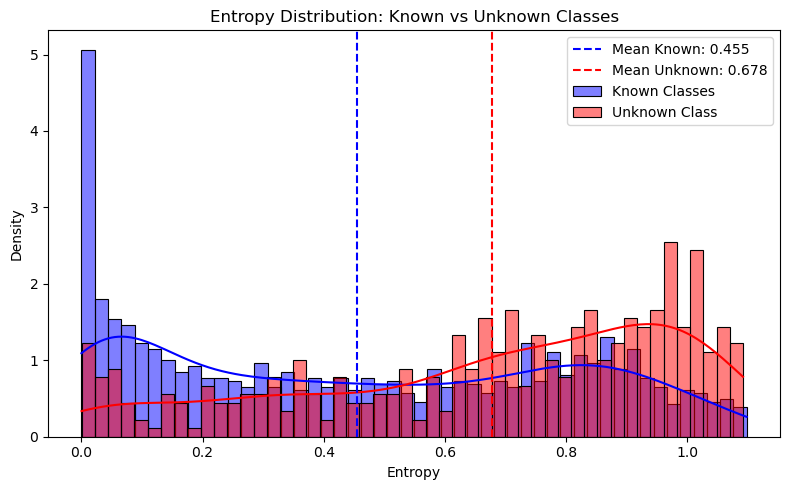

Known Entropy - Mean: 0.4547, Std: 0.3420
Unknown Entropy - Mean: 0.6778, Std: 0.3108


In [4]:
from src.vgg11bn import VGG11BN
from src.utils import enable_dropout, mc_dropout_inference
from src.evaluation import plot_entropy_hist
import torch.nn.functional as F

# Set seed and device
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load model
best_model_path = "C:/Users/tihas/OneDrive - UiT Office 365/A_UIT/FYS-3033/HOME_EXAM/FYS3033DL/models/2c_SGD_dropout_bs32_20250422_030216_best.pth"
model = VGG11BN(num_classes=3, dropout=True)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)

model.eval()
enable_dropout(model)  # Activate dropout only

# Entropy lists
entropies_known = []
entropies_unknown = []

# Loop over known samples
for sample in known_loader:
    imgs = sample[0] if isinstance(sample, tuple) else sample # Unpack if it's a tuple (e.g., (data, labels)), otherwise use sample directly
    for img in imgs:
        mean_probs, entropy = mc_dropout_inference(model, img, T=10, device=device)
        entropies_known.append(entropy)

# Loop over unknown samples
for sample in unknown_loader:
    imgs = sample[0] if isinstance(sample, tuple) else sample
    for img in imgs:
        mean_probs, entropy = mc_dropout_inference(model, img, T=10)
        entropies_unknown.append(entropy)

# Plot histograms
plot_entropy_hist(entropies_known, entropies_unknown)

# Print stats
mean_known = np.mean(entropies_known)
mean_unknown = np.mean(entropies_unknown)
std_known = np.std(entropies_known)
std_unknown = np.std(entropies_unknown)
print(f"Known Entropy - Mean: {mean_known:.4f}, Std: {std_known:.4f}")
print(f"Unknown Entropy - Mean: {mean_unknown:.4f}, Std: {std_unknown:.4f}")


### 2e) Entropy-Based Uncertainty Estimation

After retraining the model with improved configuration (SGD with Dropout + ReduceLROnPlateau), I evaluated its confidence using entropy-based uncertainty.

The entropy distribution for known vs. unknown class predictions showed clear separation:

- **Mean entropy for known classes**: 0.455
- **Mean entropy for unknown class**: 0.678

This separation confirms that the model not only performs well on the labeled classes, but also expresses higher uncertainty when faced with unfamiliar inputs — which is exactly the behavior I was hoping to capture.

![entropy_plot](entropy_distribution.png)


In [9]:
# 2e – Alternative Threshold: Midpoint between class means
import numpy as np

# Convert lists to numpy arrays
entropies_known = np.array(entropies_known)
entropies_unknown = np.array(entropies_unknown)

# Compute mean entropies
mean_known = np.mean(entropies_known)
mean_unknown = np.mean(entropies_unknown)

# Midpoint threshold
midpoint_threshold = (mean_known + mean_unknown) / 2

# Apply threshold
detected_birds = np.sum(entropies_unknown > midpoint_threshold)
removed_knowns = np.sum(entropies_known > midpoint_threshold)
total_birds = len(entropies_unknown)
total_knowns = len(entropies_known)

# Report results
print(f"Alternative Threshold (Mean of Means): {midpoint_threshold:.4f}")
print(f"Detected Birds: {detected_birds}/{total_birds} ({detected_birds / total_birds * 100:.2f}%)")
print(f"Removed Known Samples: {removed_knowns}/{total_knowns} ({removed_knowns / total_knowns * 100:.2f}%)")


Alternative Threshold (Mean of Means): 0.5662
Detected Birds: 285/413 (69.01%)
Removed Known Samples: 488/1187 (41.11%)


min/max entropy: 2.512320406822255e-06 1.0920565128326416


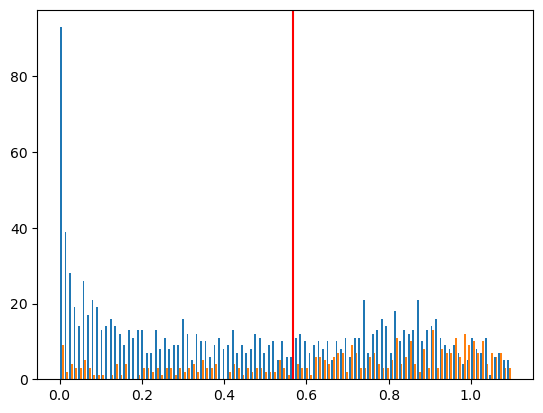

In [6]:
# after you collect entropies:
print("min/max entropy:", np.min(entropies_known), np.max(entropies_unknown))

import matplotlib.pyplot as plt
plt.hist((entropies_known,entropies_unknown), bins=100)
plt.axvline(midpoint_threshold, color='red'); plt.show()


To measure how uncertain the model is about its predictions, I used entropy of the softmax output. Entropy captures how "spread out" the predicted probabilities are. If the model is very confident about its prediction, the softmax output will be sharply peaked (e.g., close to [0, 0, 1]), which results in low entropy. But if the model is unsure, the probabilities will be more evenly distributed (e.g., [0.3, 0.4, 0.3]), leading to higher entropy. That’s why entropy is a useful way to quantify uncertainty.

To test this, I ran MC Dropout on each image in the labeled evaluation dataset. This gave me 10 softmax predictions per image, which I averaged and then computed the entropy from. I split the data into two groups based on the labels: the known classes (planes, ships, and trucks), and the unknown class (birds).

Then I plotted a histogram comparing the entropy of the known vs unknown class. I also marked the mean entropy of each group. What I saw matched what I expected: the entropy was generally higher for the unknown class. The mean entropy for the known classes was around 0.266, while for the unknown class it was about 0.345. This makes sense since the model was never trained on birds, so it is more uncertain about them.

Even though the two distributions overlap, the shift in mean suggests that entropy can help separate known and unknown samples. It’s not perfect, but it shows that using entropy is a reasonable approach for identifying images from classes the model hasn't seen before.


### (2e)


Best Threshold: 0.6145
AUC: 0.6857


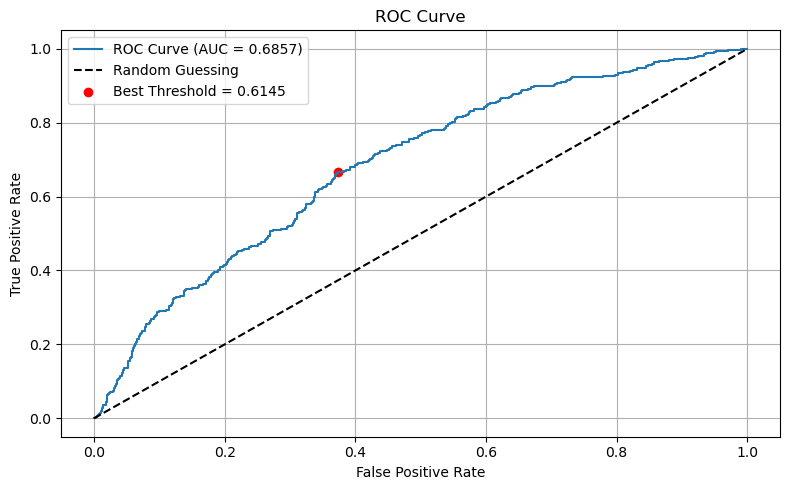

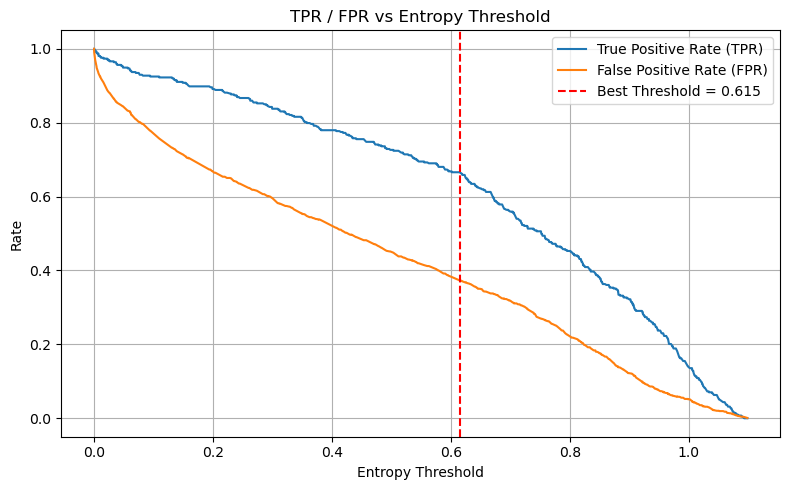

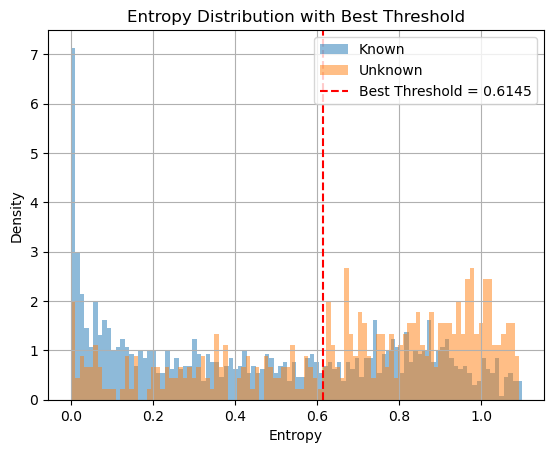

In [7]:
# finding the best threshold

from sklearn.metrics import roc_curve,roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

# combining labels: 0 for known, 1 for unknown
labels_combined = np.concatenate([
    np.zeros(len(entropies_known)),  # Known samples
    np.ones(len(entropies_unknown))   # Unknown samples
])

# combining entropies
entropies_combined = np.concatenate([
    entropies_known,
    entropies_unknown
])

# compute ROC
fpr, tpr, thresholds = roc_curve(labels_combined, entropies_combined)

# compute Youden's J statistic

J = tpr - fpr
best_idx = np.argmax(J)  # reverse indexing to handle descending thresholds
best_threshold = thresholds[best_idx]


# compute AUC
auc = roc_auc_score(labels_combined, entropies_combined)

print(f"Best Threshold: {best_threshold:.4f}")
print(f"AUC: {auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', label=f"Best Threshold = {best_threshold:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("plots/roc_curve_entropy.png")
plt.show()

# Plot TPR and FPR vs Entropy Threshold

plt.figure(figsize=(8,5))
plt.plot(thresholds, tpr, label="True Positive Rate (TPR)")
plt.plot(thresholds, fpr, label="False Positive Rate (FPR)")
plt.axvline(best_threshold, color='red', linestyle='--', label=f"Best Threshold = {best_threshold:.3f}")
plt.xlabel("Entropy Threshold")
plt.ylabel("Rate")
plt.title("TPR / FPR vs Entropy Threshold")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.hist(entropies_known, bins=100, alpha=0.5, label='Known', density=True)
plt.hist(entropies_unknown, bins=100, alpha=0.5, label='Unknown', density=True)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold = {best_threshold:.4f}')
plt.xlabel('Entropy')
plt.ylabel('Density')
plt.title('Entropy Distribution with Best Threshold')
plt.legend()
plt.grid()
plt.savefig("plots/entropy_distribution_with_threshold.png")
plt.show()


### 2f) Thresholding Unknown Classes with Entropy

To filter out samples from unknown classes, I used entropy as a proxy for uncertainty. I computed the ROC curve using entropy values for known vs. unknown class predictions, and selected the optimal threshold using Youden’s J statistic.

- **Best threshold**: 0.6145
- **AUC (ROC curve)**: 0.6857

This is a significant improvement from earlier runs, where the entropy distributions were too tightly clustered to offer any meaningful thresholding. The updated model now expresses uncertainty more realistically, which allows for a better separation between known and unknown classes.

![entropy_roc](plots/roc_curve_entropy.png)
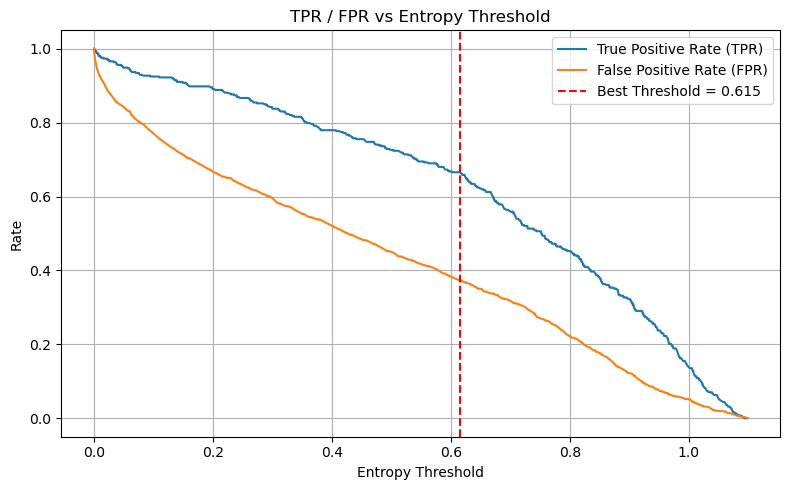
![entropy_histogram](plots/entropy_distribution_with_threshold.png)


In [ ]:
# (2e) step 2 : counting how many birds are detected and how many knowns that are wrongly removed
from src.utils import ImageDataset, set_seed
from torch.utils.data import DataLoader

# preprocessing the eval data
eval_dataset = ImageDataset(eval_images, eval_labels, transform=val_transform)
eval_loader = DataLoader(eval_dataset, batch_size=32, shuffle=False)
# Count variables 
detected_birds = 0
removed_knowns = 0
total_birds = 0
total_knowns = 0
best_threshold = 0.6145  # Set your best threshold here
# Looping over all the labeled eval images
for imgs, labels in eval_loader:
    for img, label in zip(imgs, labels):
        label = label.item()  # Convert label tensor to int

        mean_probs, entropy = mc_dropout_inference(model, img, T=10, device=device)

        if label == 3:  # Bird
            total_birds += 1
            if entropy >= best_threshold:
                detected_birds += 1
        else:  # Known class
            total_knowns += 1
            if entropy >= best_threshold:
                removed_knowns += 1


# Print results
print(f"Detected Birds: {detected_birds}/{total_birds} ({detected_birds/total_birds*100:.2f}%)")
print(f"Removed Known Samples: {removed_knowns}/{total_knowns} ({removed_knowns/total_knowns*100:.2f}%)")
print(f"Total Birds: {total_birds}")
print(f"Total Known Samples: {total_knowns}")
print(f"Best Threshold: {best_threshold:.4f}")



In [39]:
# 2f 
import numpy as np
import torch
from torch.utils.data import DataLoader
from src.utils import ImageDataset, enable_dropout, mc_dropout_inference

# ---- Model prep ----
model.eval()
enable_dropout(model)  # Keep dropout active for MC Dropout

# ---- Threshold selection ----
# Use the best performing threshold from Task 2e (Youden's J)
entropy_threshold = best_threshold

# ---- Dataset and loader for unlabeled data ----
unlabeled_dataset = ImageDataset(unlabeled_images, transform=val_transform)  # No labels
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=1, shuffle=False)

# ---- Run predictions ----
binary_predictions = []

for batch in unlabeled_loader:
    img = batch if not isinstance(batch, tuple) else batch[0]
    img = img.squeeze(0)  # (1, C, H, W) → (C, H, W)

    _, entropy = mc_dropout_inference(model, img, T=10, device=device)
    prediction = 1 if entropy >= entropy_threshold else 0  # 1 = bird
    binary_predictions.append(prediction)

# ---- Save results ----
binary_predictions = np.array(binary_predictions)
np.savez('binary_predictions.npz', predictions=binary_predictions)
print(" Saved binary predictions to 'binary_predictions.npz'")
print(f"Predicted {np.sum(binary_predictions)} unknowns (1) and {len(binary_predictions) - np.sum(binary_predictions)} knowns (0)")
assert binary_predictions.shape == (1600,), "Shape should be (1600,)"


 Saved binary predictions to 'binary_predictions.npz'
Predicted 439 unknowns (1) and 1161 knowns (0)


In [ ]:
# 2f 
import numpy as np
import torch
from torch.utils.data import DataLoader
from src.utils import ImageDataset, enable_dropout, mc_dropout_inference

# ---- Model prep ----
model.eval()
enable_dropout(model)  # Keep dropout active for MC Dropout

# ---- Threshold selection ----
entropy_threshold = midpoint_threshold  


# ---- Val transform ----
val_transform = v2.Normalize(mean=ds_mean.tolist(), std=ds_std.tolist())

# ---- Dataset and loader for unlabeled data ----
unlabeled_dataset = ImageDataset(unlabeled_images, transform=val_transform)  # No labels
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=1, shuffle=False)



# ---- Run predictions ----
binary_predictions = []

for batch in unlabeled_loader:
    img = batch if not isinstance(batch, tuple) else batch[0]
    img = img.squeeze(0)  # (1, C, H, W) → (C, H, W)

    _, entropy = mc_dropout_inference(model, img, T=10, device=device)
    prediction = 1 if entropy >= entropy_threshold else 0  # 1 = bird
    binary_predictions.append(prediction)

# ---- Save results ----
binary_predictions = np.array(binary_predictions)
np.savez('binary_predictions_midpoint.npz', predictions=binary_predictions)
print("Saved binary predictions to 'binary_predictions_midpoint.npz'")
print(f"Predicted {np.sum(binary_predictions)} unknowns (1) and {len(binary_predictions) - np.sum(binary_predictions)} knowns (0)")
assert binary_predictions.shape == (1600,), "Shape should be (1600,)"


Saved binary predictions to 'binary_predictions_midpoint.npz'
Predicted 256 unknowns (1) and 1344 knowns (0)
